# S3: Multi-Model Stratified Evaluation — Norman 2019

Compares any number of saved models (reads `per_perturbation_results.csv`) with:
- GI-type stratification (additive / synergistic / suppressive)
- Seen-level breakdown (seen0 / seen1 / seen2)
- Additive baseline as explicit competitor
- Statistical tests (Mann-Whitney, Spearman)
- No model reloading needed — just point to save dirs

In [1]:
#1.1 Imports
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy import sparse
from sklearn.linear_model import LinearRegression
from pathlib import Path
import glob, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
print('Imports OK')

Imports OK


In [2]:
#1.2 Config — edit here
MODEL_CONFIGS = [
    {'save_dir': './save/dev_perturb_norman_leakfix-Mar05-20-28',  'label': 'S1 vanilla',  'color': '#2196F3'},
    {'save_dir': './save/dev_perturb_norman_grn_bias-Mar06-12-39', 'label': 'S2 GRN bias', 'color': '#FF9800'},
    {'save_dir': './save/norman_grn_bias_weight_v2-Mar06-17-21',   'label': 'S2 v2',       'color': '#4CAF50'},
    # add more models here
]

DATA_PATH = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
OUT_DIR   = Path('./eval_stratified_output')
OUT_DIR.mkdir(exist_ok=True)

GI_MAG_QUANTILE = 0.25   # below = 'additive' class
R2_NEOMORPHIC   = 0.5    # r2_additive < this AND high epsilon → neomorphic
print(f'Output dir: {OUT_DIR}')

Output dir: eval_stratified_output


## 2. Load & preprocess data

In [3]:
#2.1 Load adata
adata = sc.read_h5ad(DATA_PATH)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f'adata: {adata.shape}, conditions: {adata.obs["condition"].nunique()}')

adata: (89357, 5045), conditions: 277


In [4]:
#2.2 Compute control mean + per-condition deltas
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl): X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0).flatten()

cond_deltas = {}
cond_ncells = {}
for cond in adata.obs['condition'].unique():
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X): X = X.toarray()
    cond_deltas[cond] = X.mean(axis=0).flatten() - ctrl_mean
    cond_ncells[cond] = mask.sum()

print(f'Control cells: {ctrl_mask.sum()}, conditions with deltas: {len(cond_deltas)}')

Control cells: 7353, conditions with deltas: 277


In [5]:
#2.3 Parse conditions → singles / combos
def parse_cond(cond):
    if '+' not in cond: return cond, None, False
    a, b = cond.split('+')[:2]
    if a == 'ctrl' and b == 'ctrl': return None, None, False
    if a == 'ctrl': return b, None, False
    if b == 'ctrl': return a, None, False
    return a, b, True

single_deltas = {}
for cond in adata.obs['condition'].unique():
    ga, gb, is_combo = parse_cond(cond)
    if ga and not is_combo:
        single_deltas[ga] = cond_deltas[cond]

combos = [{'condition': c, 'gene_a': parse_cond(c)[0], 'gene_b': parse_cond(c)[1]}
          for c in adata.obs['condition'].unique() if parse_cond(c)[2]]
combos_df = pd.DataFrame(combos)
print(f'Singles: {len(single_deltas)}, Combos: {len(combos_df)}')

Singles: 103, Combos: 128


## 3. GI Computation & Classification

In [6]:
#3.1 GI scores + manifold decomposition
gi_records = []
for _, row in combos_df.iterrows():
    cond, ga, gb = row['condition'], row['gene_a'], row['gene_b']
    if ga not in single_deltas or gb not in single_deltas: continue
    delta_ab = cond_deltas[cond]
    delta_a  = single_deltas[ga]
    delta_b  = single_deltas[gb]
    additive  = delta_a + delta_b
    gi_vec    = delta_ab - additive
    top20_idx = np.argsort(np.abs(delta_ab))[-20:]

    # Manifold decomposition: delta_ab = c1*delta_a + c2*delta_b + epsilon
    X_reg = np.column_stack([delta_a, delta_b])
    reg   = LinearRegression(fit_intercept=False).fit(X_reg, delta_ab)
    c1, c2 = reg.coef_
    eps    = delta_ab - reg.predict(X_reg)
    ss_tot = np.sum((delta_ab - delta_ab.mean())**2)
    r2     = 1 - np.sum(eps**2) / (ss_tot + 1e-10)

    r_add, _ = pearsonr(additive[top20_idx], delta_ab[top20_idx])
    mse_add  = np.mean((additive[top20_idx] - delta_ab[top20_idx])**2)

    gi_records.append({
        'condition': cond, 'gene_a': ga, 'gene_b': gb,
        'gi_magnitude_top20':  np.linalg.norm(gi_vec[top20_idx]),
        'gi_mean_signed_top20': np.mean(gi_vec[top20_idx]),
        'gi_magnitude_all':    np.linalg.norm(gi_vec),
        'r2_additive': r2, 'c1': c1, 'c2': c2,
        'epsilon_norm_top20':  np.linalg.norm(eps[top20_idx]),
        'pcc_additive_top20':  float(r_add) if not np.isnan(r_add) else 0.0,
        'mse_additive_top20':  mse_add,
    })

gi_df = pd.DataFrame(gi_records)
print(f'GI computed for {len(gi_df)} combos')

GI computed for 128 combos


In [7]:
#3.2 GI type classification
q25 = gi_df['gi_magnitude_top20'].quantile(GI_MAG_QUANTILE)
q75 = gi_df['gi_magnitude_top20'].quantile(0.75)

def classify_gi(row):
    if row['r2_additive'] < R2_NEOMORPHIC and row['epsilon_norm_top20'] > q75:
        return 'neomorphic'
    if row['gi_magnitude_top20'] <= q25:
        return 'additive'
    if row['gi_mean_signed_top20'] > 0:
        return 'synergistic'
    return 'suppressive'

gi_df['gi_type'] = gi_df.apply(classify_gi, axis=1)
print(f'Q25={q25:.3f}, Q75={q75:.3f}')
print(gi_df['gi_type'].value_counts().to_string())
gi_df.to_csv(OUT_DIR / 'gi_annotations.csv', index=False)
print(f'Saved: {OUT_DIR}/gi_annotations.csv')

Q25=0.971, Q75=1.944
gi_type
suppressive    49
synergistic    47
additive       32
Saved: eval_stratified_output/gi_annotations.csv


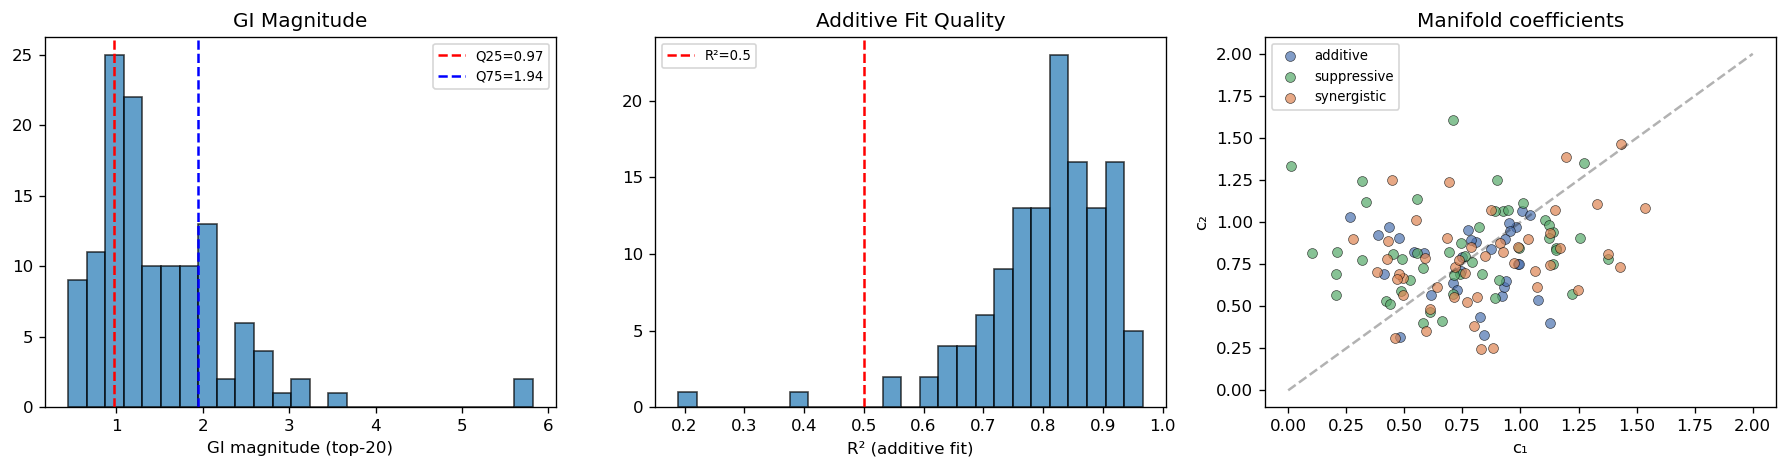

In [8]:
#3.3 GI diagnostics plot
palette = {'additive': '#4C72B0', 'synergistic': '#DD8452', 'suppressive': '#55A868', 'neomorphic': '#C44E52'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(gi_df['gi_magnitude_top20'], bins=25, edgecolor='k', alpha=0.7)
axes[0].axvline(q25, color='r', ls='--', label=f'Q25={q25:.2f}')
axes[0].axvline(q75, color='b', ls='--', label=f'Q75={q75:.2f}')
axes[0].set_xlabel('GI magnitude (top-20)'); axes[0].set_title('GI Magnitude'); axes[0].legend(fontsize=8)

axes[1].hist(gi_df['r2_additive'], bins=25, edgecolor='k', alpha=0.7)
axes[1].axvline(R2_NEOMORPHIC, color='r', ls='--', label=f'R²={R2_NEOMORPHIC}')
axes[1].set_xlabel('R² (additive fit)'); axes[1].set_title('Additive Fit Quality'); axes[1].legend(fontsize=8)

for gt in gi_df['gi_type'].unique():
    sub = gi_df[gi_df['gi_type'] == gt]
    axes[2].scatter(sub['c1'], sub['c2'], c=palette.get(gt,'gray'), label=gt, alpha=0.7, edgecolors='k', lw=0.4, s=35)
axes[2].plot([0,2],[0,2],'k--',alpha=0.3); axes[2].set_xlabel('c₁'); axes[2].set_ylabel('c₂')
axes[2].set_title('Manifold coefficients'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Seen-Level + Merge Annotations

In [9]:
#4.1 Seen-level classification (GEARS convention)
train_mask = adata.obs['split'] == 'train'
train_conds = set(adata.obs.loc[train_mask, 'condition'].unique())
train_singles = set()
for cond in train_conds:
    ga, gb, is_c = parse_cond(cond)
    if ga: train_singles.add(ga)
    if gb: train_singles.add(gb)

def get_seen_level(pert):
    ga, gb, is_c = parse_cond(pert)
    if not is_c: return 'single'
    return f'seen{int(ga in train_singles) + int(gb in train_singles)}'

# Build GI lookup (both orderings)
gi_lookup = {}
for _, r in gi_df.iterrows():
    gi_lookup[r['condition']] = r
    gi_lookup[f"{r['gene_b']}+{r['gene_a']}"] = r

print(f'Train singles known: {len(train_singles)}')

Train singles known: 69


## 5. Load Model Results & Annotate

In [10]:
#5.1 Load per_perturbation_results.csv from each model
model_dfs = {}  # label → annotated DataFrame
missing_models = []

for cfg in MODEL_CONFIGS:
    csv_path = Path(cfg['save_dir']) / 'per_perturbation_results.csv'
    if not csv_path.exists():
        print(f'WARNING: not found: {csv_path}')
        missing_models.append(cfg['label'])
        continue
    df = pd.read_csv(csv_path)
    label = cfg['label']

    # Annotate GI type + seen level
    rows = []
    for _, r in df.iterrows():
        pert = r['perturbation']
        base = r.to_dict()
        base['seen_level'] = get_seen_level(pert)
        if pert in gi_lookup:
            gi_row = gi_lookup[pert]
            for col in ['gi_type','gi_magnitude_top20','r2_additive',
                        'epsilon_norm_top20','c1','c2','pcc_additive_top20','mse_additive_top20']:
                base[col] = gi_row[col]
        else:
            base['gi_type'] = 'single' if base['seen_level'] == 'single' else 'no_data'
            for col in ['gi_magnitude_top20','r2_additive','epsilon_norm_top20',
                        'c1','c2','pcc_additive_top20','mse_additive_top20']:
                base[col] = np.nan
        rows.append(base)

    model_dfs[label] = pd.DataFrame(rows)
    print(f'[{label}] loaded {len(df)} perturbations from {csv_path}')

if missing_models:
    print(f'\nMissing: {missing_models} — skipped')
labels_ok = list(model_dfs.keys())
colors_map = {cfg['label']: cfg['color'] for cfg in MODEL_CONFIGS}

[S1 vanilla] loaded 114 perturbations from save/dev_perturb_norman_leakfix-Mar05-20-28/per_perturbation_results.csv
[S2 GRN bias] loaded 114 perturbations from save/dev_perturb_norman_grn_bias-Mar06-12-39/per_perturbation_results.csv
[S2 v2] loaded 114 perturbations from save/norman_grn_bias_weight_v2-Mar06-17-21/per_perturbation_results.csv


## 6. Summary Tables

In [11]:
#6.1 Overall summary table (all models)
print('=' * 80)
print('OVERALL SUMMARY — PCC top-20 DE genes')
print('=' * 80)
print(f'{"Model":<25} {"n":>4}  {"Mean":>8} {"Median":>8} {"Std":>8}')
print('-' * 60)
for label in labels_ok:
    df = model_dfs[label]
    v = df['pcc_top20']
    print(f'{label:<25} {len(v):>4}  {v.mean():>8.4f} {v.median():>8.4f} {v.std():>8.4f}')

OVERALL SUMMARY — PCC top-20 DE genes
Model                        n      Mean   Median      Std
------------------------------------------------------------
S1 vanilla                 114    0.5411   0.6395   0.3293
S2 GRN bias                114    0.5379   0.5737   0.3661
S2 v2                      114    0.5872   0.6324   0.3744


In [12]:
#6.2 GI-stratified table — each model vs additive baseline
gi_order = ['additive', 'synergistic', 'suppressive', 'neomorphic']

for label in labels_ok:
    df = model_dfs[label]
    combo_df = df[df['gi_type'].isin(gi_order)].copy()
    combo_df['delta_pcc'] = combo_df['pcc_top20'] - combo_df['pcc_additive_top20']

    print(f'\n--- {label} ---')
    print(f'{"GI Type":<14} {"n":>3}  {"Model PCC":>10} {"Add. PCC":>10} {"ΔPCC":>8}')
    print('-' * 52)
    for gi in gi_order:
        sub = combo_df[combo_df['gi_type'] == gi]
        if len(sub) == 0: continue
        print(f'{gi:<14} {len(sub):>3}  '
              f'{sub["pcc_top20"].mean():>+.3f}±{sub["pcc_top20"].std():.3f}  '
              f'{sub["pcc_additive_top20"].mean():>+.3f}±{sub["pcc_additive_top20"].std():.3f}  '
              f'{sub["delta_pcc"].mean():>+.3f}')
    print(f'{"ALL combos":<14} {len(combo_df):>3}  '
          f'{combo_df["pcc_top20"].mean():>+.3f}±{combo_df["pcc_top20"].std():.3f}  '
          f'{combo_df["pcc_additive_top20"].mean():>+.3f}±{combo_df["pcc_additive_top20"].std():.3f}  '
          f'{combo_df["delta_pcc"].mean():>+.3f}')
    singles = df[df['seen_level'] == 'single']
    print(f'{"SINGLES":<14} {len(singles):>3}  {singles["pcc_top20"].mean():>+.3f}±{singles["pcc_top20"].std():.3f}')


--- S1 vanilla ---
GI Type          n   Model PCC   Add. PCC     ΔPCC
----------------------------------------------------
additive        19  +0.531±0.357  +0.976±0.011  -0.445
synergistic     28  +0.695±0.162  +0.962±0.025  -0.267
suppressive     30  +0.520±0.284  +0.959±0.028  -0.439
ALL combos      77  +0.587±0.278  +0.964±0.024  -0.378
SINGLES         37  +0.446±0.405

--- S2 GRN bias ---
GI Type          n   Model PCC   Add. PCC     ΔPCC
----------------------------------------------------
additive        19  +0.586±0.413  +0.976±0.011  -0.390
synergistic     28  +0.719±0.276  +0.962±0.025  -0.244
suppressive     30  +0.675±0.284  +0.959±0.028  -0.284
ALL combos      77  +0.669±0.317  +0.964±0.024  -0.296
SINGLES         37  +0.266±0.309

--- S2 v2 ---
GI Type          n   Model PCC   Add. PCC     ΔPCC
----------------------------------------------------
additive        19  +0.589±0.464  +0.976±0.011  -0.387
synergistic     28  +0.805±0.237  +0.962±0.025  -0.158
suppressive     

In [13]:
#6.3 Seen-level table — each model
print('SEEN-LEVEL BREAKDOWN')
print(f'{"":25}', end='')
for level in ['seen0','seen1','seen2','single']:
    print(f'  {level:>10}', end='')
print()
print('-' * 75)
for label in labels_ok:
    df = model_dfs[label]
    print(f'{label:<25}', end='')
    for level in ['seen0','seen1','seen2','single']:
        sub = df[df['seen_level'] == level]
        if len(sub) == 0:
            print(f'  {"N/A":>10}', end='')
        else:
            print(f'  {sub["pcc_top20"].mean():>+.3f}(n={len(sub)})', end='')
    print()

SEEN-LEVEL BREAKDOWN
                                seen0       seen1       seen2      single
---------------------------------------------------------------------------
S1 vanilla                 +0.461(n=10)  +0.595(n=52)  +0.643(n=15)  +0.446(n=37)
S2 GRN bias                +0.354(n=10)  +0.669(n=52)  +0.876(n=15)  +0.266(n=37)
S2 v2                      +0.343(n=10)  +0.727(n=52)  +0.893(n=15)  +0.333(n=37)


## 7. Plots

Shared perturbations: 114


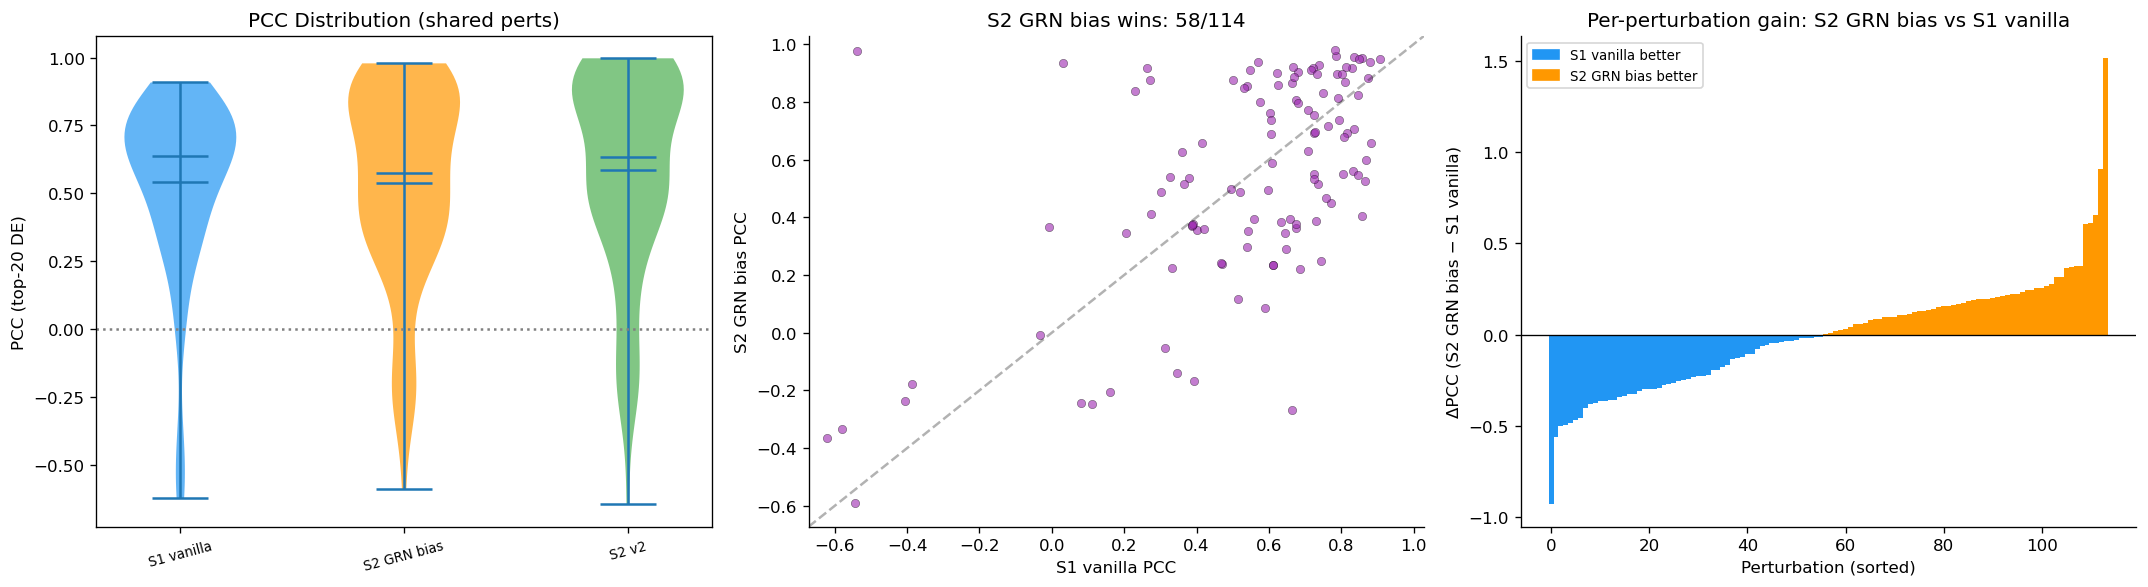

In [14]:
#7.1 PCC distribution violin — all models
# Find shared perturbations
shared_perts = sorted(set.intersection(*[set(model_dfs[l]['perturbation']) for l in labels_ok]))
print(f'Shared perturbations: {len(shared_perts)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Violin
data_violin = [model_dfs[l].set_index('perturbation').loc[shared_perts, 'pcc_top20'].values for l in labels_ok]
parts = axes[0].violinplot(data_violin, showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_map[labels_ok[i]])
    pc.set_alpha(0.7)
axes[0].set_xticks(range(1, len(labels_ok)+1))
axes[0].set_xticklabels(labels_ok, rotation=15, fontsize=8)
axes[0].set_ylabel('PCC (top-20 DE)')
axes[0].set_title('PCC Distribution (shared perts)')
axes[0].axhline(0, ls=':', c='gray')

# Pairwise scatter: first 2 models
if len(labels_ok) >= 2:
    l0, l1 = labels_ok[0], labels_ok[1]
    v0 = model_dfs[l0].set_index('perturbation').loc[shared_perts, 'pcc_top20'].values
    v1 = model_dfs[l1].set_index('perturbation').loc[shared_perts, 'pcc_top20'].values
    axes[1].scatter(v0, v1, alpha=0.6, s=25, color='#9C27B0', edgecolors='k', lw=0.3)
    lim = [min(v0.min(), v1.min())-0.05, max(v0.max(), v1.max())+0.05]
    axes[1].plot(lim, lim, 'k--', alpha=0.3)
    axes[1].set_xlim(lim); axes[1].set_ylim(lim)
    axes[1].set_xlabel(f'{l0} PCC'); axes[1].set_ylabel(f'{l1} PCC')
    n_wins = (v1 > v0).sum()
    axes[1].set_title(f'{l1} wins: {n_wins}/{len(shared_perts)}')
    sns.despine(ax=axes[1])

# Delta bar: model[1] - model[0]
if len(labels_ok) >= 2:
    delta = v1 - v0
    order = np.argsort(delta)
    bar_cols = [colors_map[l1] if d > 0 else colors_map[l0] for d in delta[order]]
    axes[2].bar(range(len(delta)), delta[order], color=bar_cols, width=1.0)
    axes[2].axhline(0, color='black', lw=0.8)
    axes[2].set_xlabel('Perturbation (sorted)')
    axes[2].set_ylabel(f'ΔPCC ({l1} − {l0})')
    axes[2].set_title(f'Per-perturbation gain: {l1} vs {l0}')
    patch0 = mpatches.Patch(color=colors_map[l0], label=f'{l0} better')
    patch1 = mpatches.Patch(color=colors_map[l1], label=f'{l1} better')
    axes[2].legend(handles=[patch0, patch1], fontsize=8)
    sns.despine(ax=axes[2])

plt.tight_layout()
plt.savefig(OUT_DIR / 'pcc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

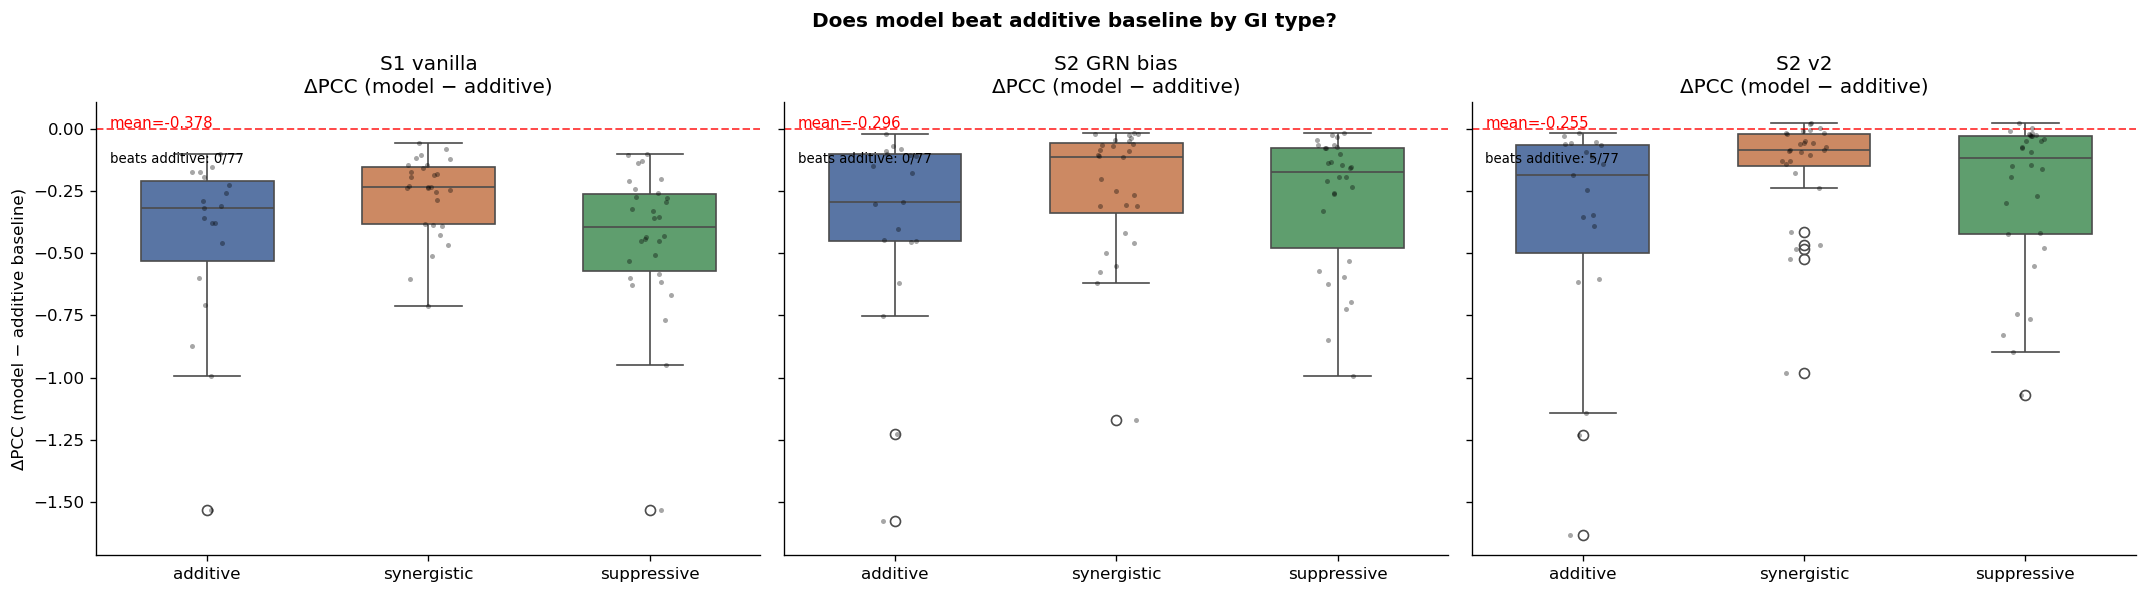

In [15]:
#7.2 ΔPCC (model - additive) by GI type — one panel per model
n_models = len(labels_ok)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5), sharey=True)
if n_models == 1: axes = [axes]
gi_order_plot = [t for t in gi_order if t in gi_df['gi_type'].values]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].copy()
    combo_df = df[df['gi_type'].isin(gi_order_plot)].copy()
    combo_df['delta_pcc'] = combo_df['pcc_top20'] - combo_df['pcc_additive_top20']

    sns.boxplot(data=combo_df, x='gi_type', y='delta_pcc', order=gi_order_plot,
                palette=palette, ax=ax, width=0.6)
    sns.stripplot(data=combo_df, x='gi_type', y='delta_pcc', order=gi_order_plot,
                  color='black', alpha=0.35, size=3, ax=ax)
    ax.axhline(0, color='red', ls='--', alpha=0.7, lw=1.2)
    ax.set_title(f'{label}\nΔPCC (model − additive)')
    ax.set_xlabel('')
    mean_d = combo_df['delta_pcc'].mean()
    ax.text(0.02, 0.97, f'mean={mean_d:+.3f}', transform=ax.transAxes,
            fontsize=9, va='top', color='red')
    wins = (combo_df['delta_pcc'] > 0).sum()
    ax.text(0.02, 0.89, f'beats additive: {wins}/{len(combo_df)}', transform=ax.transAxes,
            fontsize=8, va='top')
    sns.despine(ax=ax)

axes[0].set_ylabel('ΔPCC (model − additive baseline)')
plt.suptitle('Does model beat additive baseline by GI type?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'delta_pcc_by_gi_type.png', dpi=150, bbox_inches='tight')
plt.show()

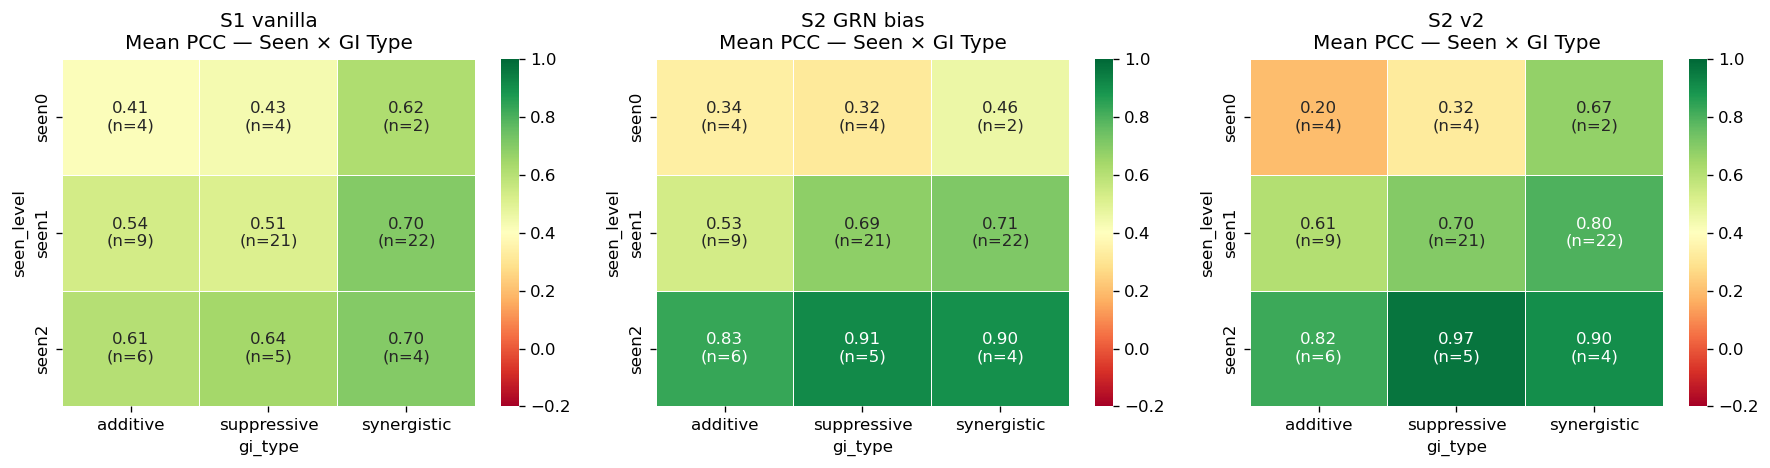

In [16]:
#7.3 Cross-tab heatmap: Seen Level × GI Type (PCC) — one per model
n_models = len(labels_ok)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1: axes = [axes]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label]
    df_cross = df[df['gi_type'].isin(gi_order)]
    cross_pcc = df_cross.pivot_table(values='pcc_top20', index='seen_level',
                                     columns='gi_type', aggfunc='mean')
    cross_n = df_cross.pivot_table(values='perturbation', index='seen_level',
                                   columns='gi_type', aggfunc='count')
    # Combine mean + count as annotation
    annot = cross_pcc.round(2).astype(str)
    for col in annot.columns:
        for idx in annot.index:
            if col in cross_n.columns and idx in cross_n.index:
                n = cross_n.loc[idx, col] if not pd.isna(cross_n.loc[idx, col]) else 0
                annot.loc[idx, col] = f'{cross_pcc.loc[idx, col]:.2f}\n(n={int(n)})'
    sns.heatmap(cross_pcc, annot=annot, fmt='', cmap='RdYlGn', ax=ax,
                vmin=-0.2, vmax=1.0, linewidths=0.5, cbar=True)
    ax.set_title(f'{label}\nMean PCC — Seen × GI Type')

plt.tight_layout()
plt.savefig(OUT_DIR / 'heatmap_seen_x_gi.png', dpi=150, bbox_inches='tight')
plt.show()

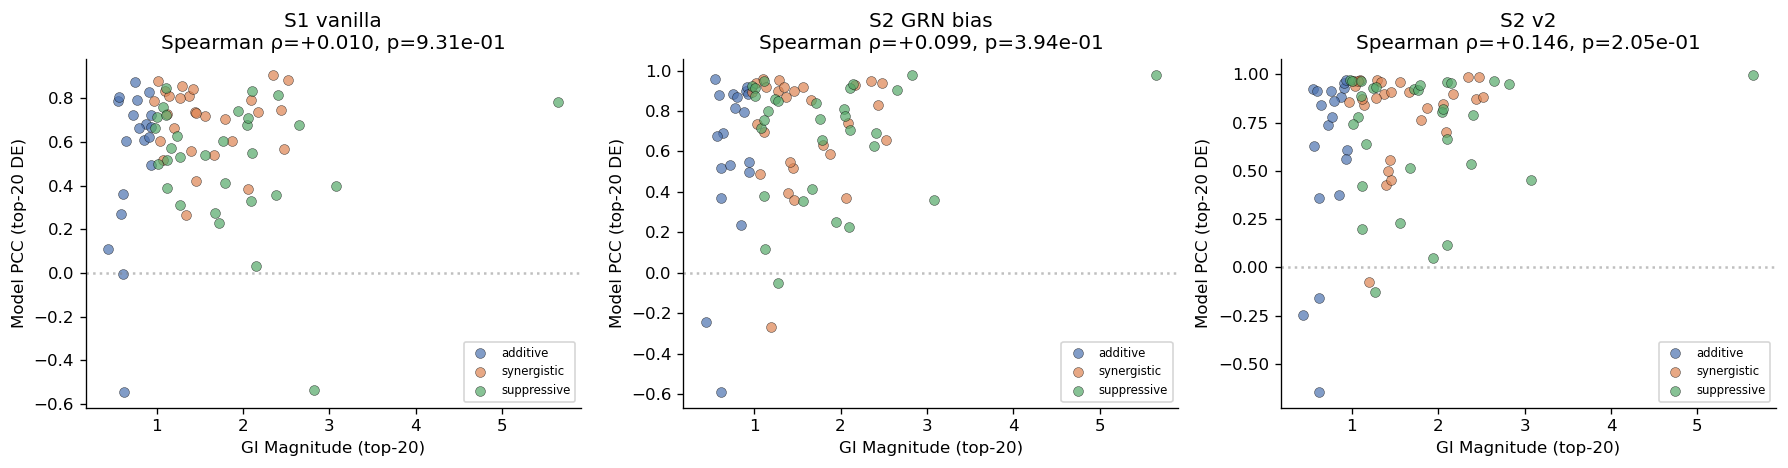

Spearman correlations (GI magnitude vs PCC):
  [S1 vanilla]  PCC: ρ=+0.010 p=0.931  |  MSE: ρ=+0.510 p=0.000
  [S2 GRN bias]  PCC: ρ=+0.099 p=0.394  |  MSE: ρ=+0.453 p=0.000
  [S2 v2]  PCC: ρ=+0.146 p=0.205  |  MSE: ρ=+0.356 p=0.001


In [17]:
#7.4 GI magnitude vs prediction error (Spearman) — per model
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1: axes = [axes]

for ax, label in zip(axes, labels_ok):
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20'])
    rho, pval = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    for gt in gi_order_plot:
        sub = df[df['gi_type'] == gt]
        ax.scatter(sub['gi_magnitude_top20'], sub['pcc_top20'],
                   c=palette[gt], label=gt, alpha=0.7, edgecolors='k', lw=0.3, s=35)
    ax.set_xlabel('GI Magnitude (top-20)')
    ax.set_ylabel('Model PCC (top-20 DE)')
    ax.set_title(f'{label}\nSpearman ρ={rho:+.3f}, p={pval:.2e}')
    ax.legend(fontsize=7)
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_magnitude_vs_pcc.png', dpi=150, bbox_inches='tight')
plt.show()

print('Spearman correlations (GI magnitude vs PCC):')
for label in labels_ok:
    df = model_dfs[label].dropna(subset=['gi_magnitude_top20'])
    rho_pcc, p_pcc = spearmanr(df['gi_magnitude_top20'], df['pcc_top20'])
    rho_mse, p_mse = spearmanr(df['gi_magnitude_top20'], df['mse_top20'])
    print(f'  [{label}]  PCC: ρ={rho_pcc:+.3f} p={p_pcc:.3f}  |  MSE: ρ={rho_mse:+.3f} p={p_mse:.3f}')

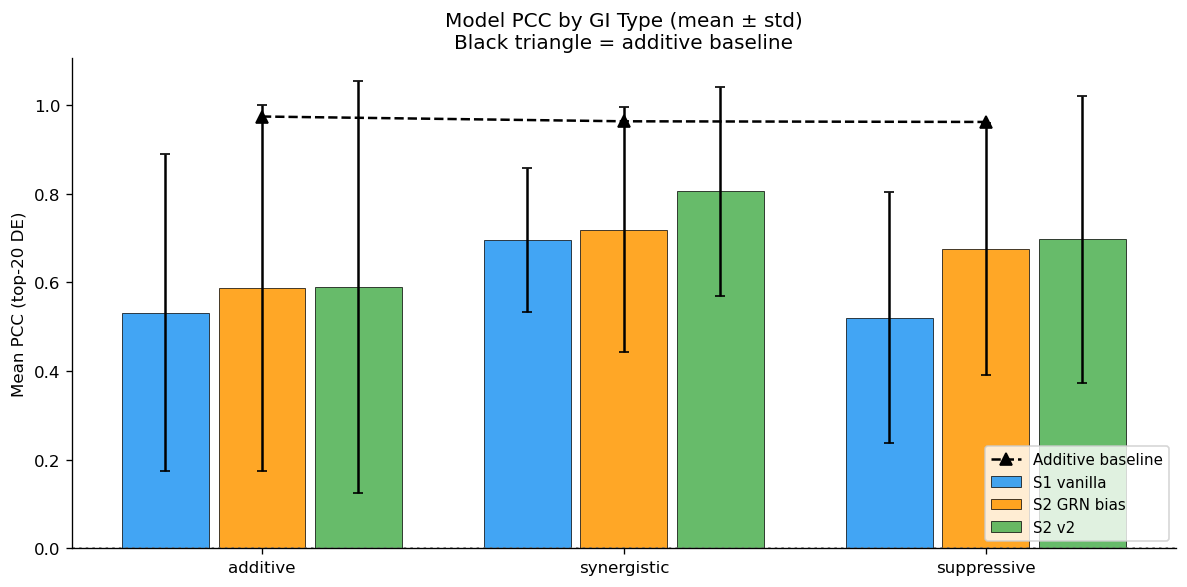

In [18]:
#7.5 Multi-model GI-type bar summary (mean PCC per GI type, grouped)
gi_types_present = [t for t in gi_order if any(
    t in model_dfs[l]['gi_type'].values for l in labels_ok)]

x = np.arange(len(gi_types_present))
width = 0.8 / len(labels_ok)
fig, ax = plt.subplots(figsize=(10, 5))

for i, label in enumerate(labels_ok):
    df = model_dfs[label]
    means = [df[df['gi_type'] == gt]['pcc_top20'].mean() for gt in gi_types_present]
    stds  = [df[df['gi_type'] == gt]['pcc_top20'].std()  for gt in gi_types_present]
    offset = (i - len(labels_ok)/2 + 0.5) * width
    ax.bar(x + offset, means, width*0.9, yerr=stds, capsize=3,
           label=label, color=colors_map[label], alpha=0.85, edgecolor='k', lw=0.5)

# Additive baseline (same for all models)
add_means = []
for gt in gi_types_present:
    sub = gi_df[gi_df['gi_type'] == gt]
    add_means.append(sub['pcc_additive_top20'].mean() if len(sub) > 0 else np.nan)
ax.plot(x, add_means, 'k^--', markersize=7, label='Additive baseline', zorder=5)

ax.set_xticks(x); ax.set_xticklabels(gi_types_present)
ax.set_ylabel('Mean PCC (top-20 DE)')
ax.set_title('Model PCC by GI Type (mean ± std)\nBlack triangle = additive baseline')
ax.legend(fontsize=9); ax.axhline(0, color='gray', ls=':')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'gi_type_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Statistical Tests

In [19]:
#8.1 Mann-Whitney: ΔPCC across GI types (per model)
print('Mann-Whitney U: ΔPCC across GI types')
print('(does GI type affect how much model beats additive?)')
for label in labels_ok:
    df = model_dfs[label].copy()
    combo_df = df[df['gi_type'].isin(gi_order_plot)].copy()
    combo_df['delta_pcc'] = combo_df['pcc_top20'] - combo_df['pcc_additive_top20']
    print(f'\n  [{label}]')
    ref = combo_df.loc[combo_df['gi_type'] == 'additive', 'delta_pcc']
    for gt in ['synergistic', 'suppressive', 'neomorphic']:
        other = combo_df.loc[combo_df['gi_type'] == gt, 'delta_pcc']
        if len(ref) < 3 or len(other) < 3:
            print(f'    additive vs {gt}: not enough data')
            continue
        stat, pval = mannwhitneyu(ref, other, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f'    additive vs {gt:12s}: U={stat:.0f}, p={pval:.4f} {sig}')

Mann-Whitney U: ΔPCC across GI types
(does GI type affect how much model beats additive?)

  [S1 vanilla]
    additive vs synergistic : U=182, p=0.0703 ns
    additive vs suppressive : U=307, p=0.6591 ns
    additive vs neomorphic: not enough data

  [S2 GRN bias]
    additive vs synergistic : U=201, p=0.1620 ns
    additive vs suppressive : U=244, p=0.4059 ns
    additive vs neomorphic: not enough data

  [S2 v2]
    additive vs synergistic : U=169, p=0.0364 *
    additive vs suppressive : U=224, p=0.2144 ns
    additive vs neomorphic: not enough data


In [20]:
#8.2 Best model wins per perturbation
if len(labels_ok) >= 2:
    shared_idx = list(shared_perts)
    pcc_matrix = pd.DataFrame({
        l: model_dfs[l].set_index('perturbation').loc[shared_idx, 'pcc_top20']
        for l in labels_ok
    })
    pcc_matrix['best'] = pcc_matrix.idxmax(axis=1)
    print('Best model wins (shared perturbations):')
    print(pcc_matrix['best'].value_counts().to_string())
    print(f'\nTotal shared: {len(pcc_matrix)}')

    # Show top improvements / regressions
    if len(labels_ok) >= 2:
        l0, l1 = labels_ok[0], labels_ok[1]
        pcc_matrix['delta'] = pcc_matrix[l1] - pcc_matrix[l0]
        print(f'\nTop 10 where {l1} most improved vs {l0}:')
        print(pcc_matrix[['delta',l0,l1]].nlargest(10,'delta').round(4).to_string())
        print(f'\nTop 10 where {l1} most regressed vs {l0}:')
        print(pcc_matrix[['delta',l0,l1]].nsmallest(10,'delta').round(4).to_string())

Best model wins (shared perturbations):
best
S2 v2          50
S1 vanilla     44
S2 GRN bias    20

Total shared: 114

Top 10 where S2 GRN bias most improved vs S1 vanilla:
               delta  S1 vanilla  S2 GRN bias
perturbation                                 
CEBPB+MAPK1   1.5133     -0.5375       0.9759
ETS2+MAPK1    0.9045      0.0306       0.9351
ZBTB10+SNAI1  0.6538      0.2643       0.9181
ETS2+CEBPE    0.6100      0.2290       0.8391
TGFBR2+ETS2   0.6055      0.2711       0.8766
TMSB4X+BAK1   0.3749     -0.0070       0.3678
UBASH3B+OSR2  0.3733      0.5016       0.8749
UBASH3B+CNN1  0.3680      0.5688       0.9368
DUSP9+PRTG    0.3645      0.5479       0.9123
MAP2K3+IKZF3  0.3178      0.5311       0.8489

Top 10 where S2 GRN bias most regressed vs S1 vanilla:
                delta  S1 vanilla  S2 GRN bias
perturbation                                  
FOSB+PTPN12   -0.9294      0.6632      -0.2662
ARRDC3+ctrl   -0.5605      0.3939      -0.1666
KIF18B+ctrl   -0.5026      0.58

## 9. Export

In [21]:
#9.1 Save annotated per-perturbation CSVs
for label in labels_ok:
    safe_label = label.replace(' ', '_').replace('/', '_')
    out_csv = OUT_DIR / f'eval_{safe_label}.csv'
    model_dfs[label].to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

# Combined table (shared perts only)
if len(labels_ok) >= 2:
    combined = model_dfs[labels_ok[0]][['perturbation','seen_level','gi_type',
                                         'gi_magnitude_top20','pcc_additive_top20']].copy()
    for label in labels_ok:
        safe = label.replace(' ','_')
        tmp = model_dfs[label][['perturbation','pcc_top20','mse_top20']].rename(
            columns={'pcc_top20': f'pcc_{safe}', 'mse_top20': f'mse_{safe}'})
        combined = combined.merge(tmp, on='perturbation', how='inner')
    combined.to_csv(OUT_DIR / 'eval_combined.csv', index=False)
    print(f'Saved: {OUT_DIR}/eval_combined.csv')

print('\nAll output files:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')

Saved: eval_stratified_output/eval_S1_vanilla.csv
Saved: eval_stratified_output/eval_S2_GRN_bias.csv
Saved: eval_stratified_output/eval_S2_v2.csv
Saved: eval_stratified_output/eval_combined.csv

All output files:
  delta_pcc_by_gi_type.png
  eval_S1_vanilla.csv
  eval_S2_GRN_bias.csv
  eval_S2_v2.csv
  eval_combined.csv
  gi_annotations.csv
  gi_diagnostics.png
  gi_magnitude_vs_pcc.png
  gi_type_bar_comparison.png
  heatmap_seen_x_gi.png
  pcc_distribution.png
